**Lab 8: High-Performance Big Data Analytics Using R**

**Problem Statement:
The New York City Taxi and Limousine Commission (NYC TLC) generates millions of taxi-trip records
containing information such as pickup and drop-off locations, trip timestamps, passenger count, trip
distance, fare amount, payment type, and total transaction amount. Processing and analyzing such largescale datasets using conventional approaches can lead to increased execution time and memory
consumption.**


**Name**: Yashraj Patil

**Roll no**: 23102A0071

**Department and Division**: CMPN-A

**Lab mentor**: Prof. Prakash Parmar

In [1]:
# Install packages (uses fast pre-built Linux packages when available)
os <- sub("VERSION_CODENAME=", "", grep("^VERSION_CODENAME=", readLines("/etc/os-release"), value = TRUE))
options(HTTPUserAgent = sprintf("R/%s R (%s)", getRversion(), paste(getRversion(), R.version$platform, R.version$arch, R.version$os)))
options(repos = c(CRAN = paste0("https://packagemanager.posit.co/cran/__linux__/", os, "/latest")))
install.packages(c("data.table", "ggplot2", "foreach", "doParallel", "microbenchmark", "purrr", "nanoparquet"))

Installing packages into ‘/usr/local/lib/R/site-library’
(as ‘lib’ is unspecified)

also installing the dependency ‘iterators’




In [2]:
library(data.table)
library(ggplot2)
library(foreach)
library(doParallel)
library(microbenchmark)
library(purrr)


Attaching package: ‘data.table’


The following object is masked from ‘package:base’:

    %notin%


Loading required package: iterators

Loading required package: parallel


Attaching package: ‘purrr’


The following objects are masked from ‘package:foreach’:

    accumulate, when


The following object is masked from ‘package:data.table’:

    transpose




In [3]:
options(timeout = 1800)
YEAR   <- 2024
MONTHS <- 1:3      # use 1:2 if Colab runs out of memory

dir.create("data", showWarnings = FALSE)
url   <- "https://d37ci6vzurychx.cloudfront.net/trip-data/"
files <- sprintf("yellow_tripdata_%d-%02d.parquet", YEAR, MONTHS)

for (f in files) {
  if (!file.exists(file.path("data", f))) download.file(paste0(url, f), file.path("data", f), mode = "wb")
}
download.file("https://d37ci6vzurychx.cloudfront.net/misc/taxi_zone_lookup.csv", "data/taxi_zone_lookup.csv", mode = "wb")

In [4]:
# Read only the columns we need (this also removes unnecessary attributes to save memory)
keep <- c("tpep_pickup_datetime", "tpep_dropoff_datetime", "PULocationID", "DOLocationID",
          "passenger_count", "trip_distance", "payment_type", "fare_amount",
          "tip_amount", "tolls_amount", "total_amount")

DT <- rbindlist(lapply(files, function(f) {
  x <- as.data.table(nanoparquet::read_parquet(file.path("data", f)))
  x[, ..keep]
}))

In [5]:
dim(DT)
str(DT)

[1] 9554778      11

Classes ‘data.table’ and 'data.frame':	9554778 obs. of  11 variables:
 $ tpep_pickup_datetime : POSIXct, format: "2024-01-01 00:57:55" "2024-01-01 00:03:00" ...
 $ tpep_dropoff_datetime: POSIXct, format: "2024-01-01 01:17:43" "2024-01-01 00:09:36" ...
 $ PULocationID         : int  186 140 236 79 211 148 138 246 161 113 ...
 $ DOLocationID         : int  79 236 79 211 148 141 181 231 261 113 ...
 $ passenger_count      : num  1 1 1 1 1 1 2 0 1 1 ...
 $ trip_distance        : num  1.72 1.8 4.7 1.4 0.8 ...
 $ payment_type         : num  2 1 1 1 1 1 1 2 2 2 ...
 $ fare_amount          : num  17.7 10 23.3 10 7.9 29.6 45.7 25.4 31 3 ...
 $ tip_amount           : num  0 3.75 3 2 3.2 6.9 10 0 0 0 ...
 $ tolls_amount         : num  0 0 0 0 0 0 0 0 0 0 ...
 $ total_amount         : num  22.7 18.8 31.3 17 16.1 ...
 - attr(*, ".internal.selfref")=<pointer: 0x5b0ba07a7240> 


In [6]:
summary(DT)

 tpep_pickup_datetime          tpep_dropoff_datetime          PULocationID  
 Min.   :2002-12-31 22:17:10   Min.   :2002-12-31 22:42:24   Min.   :  1.0  
 1st Qu.:2024-01-26 09:55:41   1st Qu.:2024-01-26 10:12:00   1st Qu.:132.0  
 Median :2024-02-18 15:38:32   Median :2024-02-18 15:55:02   Median :162.0  
 Mean   :2024-02-17 17:20:27   Mean   :2024-02-17 17:36:34   Mean   :165.2  
 3rd Qu.:2024-03-11 11:59:11   3rd Qu.:2024-03-11 12:16:17   3rd Qu.:234.0  
 Max.   :2024-04-01 00:34:55   Max.   :2024-04-02 18:08:46   Max.   :265.0  
                                                                            
  DOLocationID   passenger_count  trip_distance        payment_type  
 Min.   :  1.0   Min.   :0.000    Min.   :0.000e+00   Min.   :0.000  
 1st Qu.:114.0   1st Qu.:1.000    1st Qu.:1.000e+00   1st Qu.:1.000  
 Median :162.0   Median :1.000    Median :1.700e+00   Median :1.000  
 Mean   :164.2   Mean   :1.334    Mean   :4.042e+00   Mean   :1.121  
 3rd Qu.:234.0   3rd Qu.:1.000    

In [7]:
colSums(is.na(DT))              # missing values per column
DT <- na.omit(DT)               # remove missing records

sum(duplicated(DT))             # number of duplicate records
DT <- unique(DT)                # remove duplicates

nrow(DT)

tpep_pickup_datetime tpep_dropoff_datetime          PULocationID 
                    0                     0                     0 
         DOLocationID       passenger_count         trip_distance 
                    0                751962                     0 
         payment_type           fare_amount            tip_amount 
                    0                     0                     0 
         tolls_amount          total_amount 
                    0                     0

[1] 1

[1] 8802815

In [8]:
# keep only trips that start in the selected months (inconsistent dates are removed)
DT <- DT[year(tpep_pickup_datetime) == YEAR & month(tpep_pickup_datetime) %in% MONTHS]

# data types
DT[, PULocationID    := as.integer(PULocationID)]
DT[, DOLocationID    := as.integer(DOLocationID)]
DT[, passenger_count := as.integer(passenger_count)]
DT[, payment_type    := as.integer(payment_type)]

# trip duration in minutes
DT[, trip_minutes := as.numeric(difftime(tpep_dropoff_datetime, tpep_pickup_datetime, units = "mins"))]

# temporal attributes
DT[, pickup_date  := as.IDate(tpep_pickup_datetime)]
DT[, pickup_hour  := hour(tpep_pickup_datetime)]
DT[, pickup_day   := mday(tpep_pickup_datetime)]
DT[, pickup_wday  := factor(wday(tpep_pickup_datetime), levels = 1:7,
                            labels = c("Sun", "Mon", "Tue", "Wed", "Thu", "Fri", "Sat"))]
DT[, pickup_month := factor(month.abb[month(tpep_pickup_datetime)], levels = month.abb[MONTHS])]

head(DT)

tpep_pickup_datetime,tpep_dropoff_datetime,PULocationID,DOLocationID,passenger_count,trip_distance,payment_type,fare_amount,tip_amount,tolls_amount,total_amount,trip_minutes,pickup_date,pickup_hour,pickup_day,pickup_wday,pickup_month
<dttm>,<dttm>,<int>,<int>,<int>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<IDate>,<int>,<int>,<fct>,<fct>
2024-01-01 00:57:55,2024-01-01 01:17:43,186,79,1,1.72,2,17.7,0.00,0,22.70,19.80000,2024-01-01,0,1,Mon,Jan
2024-01-01 00:03:00,2024-01-01 00:09:36,140,236,1,1.80,1,10.0,3.75,0,18.75,6.60000,2024-01-01,0,1,Mon,Jan
2024-01-01 00:17:06,2024-01-01 00:35:01,236,79,1,4.70,1,23.3,3.00,0,31.30,17.91667,2024-01-01,0,1,Mon,Jan
2024-01-01 00:36:38,2024-01-01 00:44:56,79,211,1,1.40,1,10.0,2.00,0,17.00,8.30000,2024-01-01,0,1,Mon,Jan
2024-01-01 00:46:51,2024-01-01 00:52:57,211,148,1,0.80,1,7.9,3.20,0,16.10,6.10000,2024-01-01,0,1,Mon,Jan
2024-01-01 00:54:08,2024-01-01 01:26:31,148,141,1,4.70,1,29.6,6.90,0,41.50,32.38333,2024-01-01,0,1,Mon,Jan


In [9]:
# remove invalid values (zero/negative distance, fare or total, impossible passenger count or duration, unknown payment type)
DT <- DT[trip_distance > 0 & trip_distance < 100 &
         fare_amount > 0 & fare_amount < 500 &
         total_amount > 0 &
         passenger_count >= 1 & passenger_count <= 6 &
         trip_minutes >= 1 & trip_minutes <= 180 &
         payment_type >= 1 & payment_type <= 6 &
         PULocationID <= 265 & DOLocationID <= 265]

# readable payment labels
DT[, payment := factor(payment_type, levels = 1:6,
                       labels = c("Credit card", "Cash", "No charge", "Dispute", "Unknown", "Voided"))]

# remove attributes that are no longer needed
DT[, c("tpep_pickup_datetime", "tpep_dropoff_datetime", "payment_type") := NULL]

nrow(DT)

[1] 8447518

In [10]:
zones <- fread("data/taxi_zone_lookup.csv")
head(zones)

DT[zones, `:=`(PU_Borough = i.Borough, PU_Zone = i.Zone), on = c(PULocationID = "LocationID")]
DT[zones, `:=`(DO_Borough = i.Borough, DO_Zone = i.Zone), on = c(DOLocationID = "LocationID")]

head(DT)

LocationID,Borough,Zone,service_zone
<int>,<chr>,<chr>,<chr>
1,EWR,Newark Airport,EWR
2,Queens,Jamaica Bay,Boro Zone
3,Bronx,Allerton/Pelham Gardens,Boro Zone
4,Manhattan,Alphabet City,Yellow Zone
5,Staten Island,Arden Heights,Boro Zone
6,Staten Island,Arrochar/Fort Wadsworth,Boro Zone


PULocationID,DOLocationID,passenger_count,trip_distance,fare_amount,tip_amount,tolls_amount,total_amount,trip_minutes,pickup_date,pickup_hour,pickup_day,pickup_wday,pickup_month,payment,PU_Borough,PU_Zone,DO_Borough,DO_Zone
<int>,<int>,<int>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<IDate>,<int>,<int>,<fct>,<fct>,<fct>,<chr>,<chr>,<chr>,<chr>
186,79,1,1.72,17.7,0.00,0,22.70,19.80000,2024-01-01,0,1,Mon,Jan,Cash,Manhattan,Penn Station/Madison Sq West,Manhattan,East Village
140,236,1,1.80,10.0,3.75,0,18.75,6.60000,2024-01-01,0,1,Mon,Jan,Credit card,Manhattan,Lenox Hill East,Manhattan,Upper East Side North
236,79,1,4.70,23.3,3.00,0,31.30,17.91667,2024-01-01,0,1,Mon,Jan,Credit card,Manhattan,Upper East Side North,Manhattan,East Village
79,211,1,1.40,10.0,2.00,0,17.00,8.30000,2024-01-01,0,1,Mon,Jan,Credit card,Manhattan,East Village,Manhattan,SoHo
211,148,1,0.80,7.9,3.20,0,16.10,6.10000,2024-01-01,0,1,Mon,Jan,Credit card,Manhattan,SoHo,Manhattan,Lower East Side
148,141,1,4.70,29.6,6.90,0,41.50,32.38333,2024-01-01,0,1,Mon,Jan,Credit card,Manhattan,Lower East Side,Manhattan,Lenox Hill West


In [11]:
by_hour <- DT[, .(trips = .N), by = pickup_hour][order(pickup_hour)]
by_hour

pickup_hour,trips
<int>,<int>
0,221095
1,147473
2,97996
3,65508
4,40257
5,45758
6,108516
7,226844
8,321487


In [12]:
by_wday <- DT[, .(trips = .N, days = uniqueN(pickup_date)), by = pickup_wday][order(pickup_wday)]
by_wday[, avg_trips_per_day := round(trips / days)]
by_wday

pickup_wday,trips,days,avg_trips_per_day
<fct>,<int>,<int>,<dbl>
Sun,1049166,13,80705
Mon,1029414,13,79186
Tue,1167924,13,89840
Wed,1277646,13,98280
Thu,1363150,13,104858
Fri,1277812,13,98293
Sat,1282406,13,98647


In [13]:
by_month <- DT[, .(trips = .N), by = pickup_month][order(pickup_month)]
by_month

pickup_month,trips
<fct>,<int>
Jan,2713429
Feb,2709737
Mar,3024352


In [14]:
fare_hour  <- DT[, .(avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = pickup_hour][order(pickup_hour)]
fare_wday  <- DT[, .(avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = pickup_wday][order(pickup_wday)]
fare_month <- DT[, .(avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = pickup_month][order(pickup_month)]
daily      <- DT[, .(avg_fare = mean(fare_amount), revenue = sum(total_amount)), by = pickup_date][order(pickup_date)]

fare_hour
fare_wday
fare_month

pickup_hour,avg_fare,revenue
<int>,<dbl>,<dbl>
0,19.29588,6296623
1,16.93203,3742554
2,15.99829,2368864
3,17.21673,1676383
4,23.17778,1323354
5,27.56372,1747243
6,22.66025,3393598
7,18.67939,6049541
8,17.55857,8160580


pickup_wday,avg_fare,revenue
<fct>,<dbl>,<dbl>
Sun,19.34431,29593914
Mon,19.64002,29945370
Tue,18.53602,32415412
Wed,18.52510,35497520
Thu,18.81314,38391127
Fri,18.47911,35389992
Sat,17.36394,32668859


pickup_month,avg_fare,revenue
<fct>,<dbl>,<dbl>
Jan,18.38692,74238283
Feb,18.33354,74082264
Mar,19.10664,85581647


In [15]:
routes <- DT[, .(trips = .N, revenue = sum(total_amount)), by = .(PU_Zone, DO_Zone)]

top_routes   <- routes[order(-trips)][1:10]
top_revenue  <- routes[order(-revenue)][1:10]

top_routes
top_revenue

PU_Zone,DO_Zone,trips,revenue
<chr>,<chr>,<int>,<dbl>
Upper East Side South,Upper East Side North,61421,958770.9
Upper East Side North,Upper East Side South,53928,864296.7
Upper East Side North,Upper East Side North,42621,557049.2
Upper East Side South,Upper East Side South,39810,545112.3
Midtown Center,Upper East Side South,29791,506706.7
Lincoln Square East,Upper West Side South,25479,381900.5
Upper East Side South,Midtown Center,25377,424474.9
Midtown Center,Upper East Side North,25154,547800.4
Upper West Side South,Lincoln Square East,24985,361184.2


PU_Zone,DO_Zone,trips,revenue
<chr>,<chr>,<int>,<dbl>
JFK Airport,Outside of NYC,16311,2027241.8
JFK Airport,Times Sq/Theatre District,18667,1757950.2
LaGuardia Airport,Times Sq/Theatre District,17185,1319740.0
Upper East Side South,Upper East Side North,61421,958770.9
JFK Airport,Midtown South,10025,957360.3
JFK Airport,Clinton East,9988,933187.0
Upper East Side North,Upper East Side South,53928,864296.7
Times Sq/Theatre District,LaGuardia Airport,11153,846879.7
LaGuardia Airport,Midtown Center,10344,767791.2


In [16]:
cor(DT$trip_distance, DT$fare_amount)

fit <- lm(fare_amount ~ trip_distance, data = DT[sample(.N, 500000)])
coef(fit)

[1] 0.9546298

(Intercept) trip_distance 
     6.351562      3.711478

In [17]:
round(100 * prop.table(table(DT$PU_Borough, DT$payment), 1), 1)

               
                Credit card Cash No charge Dispute Unknown Voided
  Bronx                91.5  7.7       0.3     0.4     0.0    0.0
  Brooklyn             88.3 10.4       0.5     0.8     0.0    0.0
  EWR                  71.4 20.0       0.0     8.6     0.0    0.0
  Manhattan            84.4 14.5       0.3     0.8     0.0    0.0
  N/A                  60.4 28.5       5.0     6.1     0.0    0.0
  Queens               79.5 18.7       0.5     1.4     0.0    0.0
  Staten Island        38.7 50.7       6.7     4.0     0.0    0.0
  Unknown              82.1 17.1       0.3     0.5     0.0    0.0

In [18]:
speed <- DT[, .(avg_speed_mph = round(sum(trip_distance) / sum(trip_minutes / 60), 1)), by = pickup_hour][order(pickup_hour)]
speed

pickup_hour,avg_speed_mph
<int>,<dbl>
0,16.7
1,15.1
2,15.2
3,16.8
4,20.7
5,22.4
6,18.0
7,14.2
8,12.1


In [19]:
hours <- 0:23

# Base R
f_base   <- function() tapply(DT$fare_amount, DT$pickup_hour, mean)

# Functional programming
f_apply  <- function() apply(matrix(hours), 1, function(h) mean(DT$fare_amount[DT$pickup_hour == h]))
f_lapply <- function() lapply(hours, function(h) mean(DT$fare_amount[DT$pickup_hour == h]))
f_purrr  <- function() map_dbl(hours, function(h) mean(DT$fare_amount[DT$pickup_hour == h]))

# Vectorized
f_vector <- function() rowsum(DT$fare_amount, DT$pickup_hour)[, 1] / tabulate(DT$pickup_hour + 1)

# data.table
f_dt     <- function() DT[, .(avg_fare = mean(fare_amount)), by = pickup_hour]

In [20]:
results <- data.table(Approach = character(), Time_sec = numeric(), Peak_Mem_MB = numeric())

benchmark <- function(name, fn) {
  invisible(gc(reset = TRUE))
  before <- sum(gc()[, 2])
  fn()
  mem <- sum(gc()[, 6]) - before
  t <- median(microbenchmark(fn(), times = 3)$time) / 1e9
  results <<- rbind(results, data.table(Approach = name, Time_sec = round(t, 4), Peak_Mem_MB = round(mem, 1)))
}

benchmark("Base R tapply()",     f_base)
benchmark("apply()",             f_apply)
benchmark("lapply()",            f_lapply)
benchmark("purrr::map_dbl()",    f_purrr)
benchmark("Vectorized rowsum()", f_vector)
benchmark("data.table",          f_dt)

results

Approach,Time_sec,Peak_Mem_MB
<chr>,<dbl>,<dbl>
Base R tapply(),0.4739,353.8
apply(),0.8597,1327.9
lapply(),0.8011,1327.9
purrr::map_dbl(),0.8459,1328.2
Vectorized rowsum(),0.3980,289.1
data.table,0.2288,237.5


In [21]:
month_list <- split(DT$fare_amount, DT$pickup_month)   # one partition per month

boot_mean <- function(x) {
  set.seed(42)
  means <- numeric(200)
  for (i in 1:200) means[i] <- mean(sample(x, 1000000, replace = TRUE))
  mean(means)
}

In [22]:
t_seq <- system.time(res_seq <- lapply(month_list, boot_mean))[["elapsed"]]
t_seq
unlist(res_seq)

[1] 41.685

Jan      Feb      Mar 
18.38595 18.33468 19.10663

In [23]:
n_cores <- min(detectCores(), length(month_list))
n_cores

cl <- makeCluster(n_cores)
registerDoParallel(cl)

t_par <- system.time(
  res_par <- foreach(x = month_list, .export = "boot_mean") %dopar% boot_mean(x)
)[["elapsed"]]

stopCluster(cl)

t_par
unlist(res_par)

[1] 2

Warning message in e$fun(obj, substitute(ex), parent.frame(), e$data):
“already exporting variable(s): boot_mean”


[1] 38.336

[1] 18.38595 18.33468 19.10663

In [24]:
speedup <- t_seq / t_par

cat("Sequential time:", round(t_seq, 2), "sec\n")
cat("Parallel time  :", round(t_par, 2), "sec\n")
cat("Speedup        :", round(speedup, 2), "\n")

results <- rbind(results,
  data.table(Approach = "Sequential (lapply over months)", Time_sec = round(t_seq, 2), Peak_Mem_MB = NA),
  data.table(Approach = paste("Parallel (foreach, doParallel,", n_cores, "cores)"), Time_sec = round(t_par, 2), Peak_Mem_MB = NA))

Sequential time: 41.69 sec
Parallel time  : 38.34 sec
Speedup        : 1.09 


In [25]:
results

Approach,Time_sec,Peak_Mem_MB
<chr>,<dbl>,<dbl>
Base R tapply(),0.4739,353.8
apply(),0.8597,1327.9
lapply(),0.8011,1327.9
purrr::map_dbl(),0.8459,1328.2
Vectorized rowsum(),0.3980,289.1
data.table,0.2288,237.5
Sequential (lapply over months),41.6900,NA
"Parallel (foreach, doParallel, 2 cores)",38.3400,NA


In [26]:
options(repr.plot.width = 10, repr.plot.height = 5)

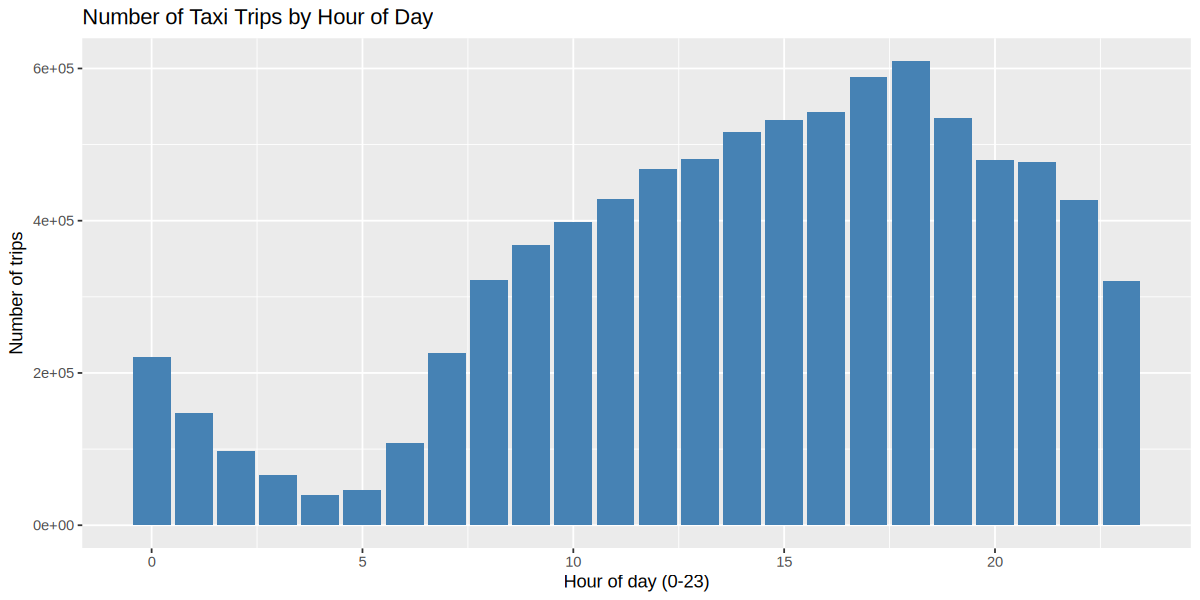

In [27]:
ggplot(by_hour, aes(x = pickup_hour, y = trips)) +
  geom_col(fill = "steelblue") +
  labs(title = "Number of Taxi Trips by Hour of Day", x = "Hour of day (0-23)", y = "Number of trips")

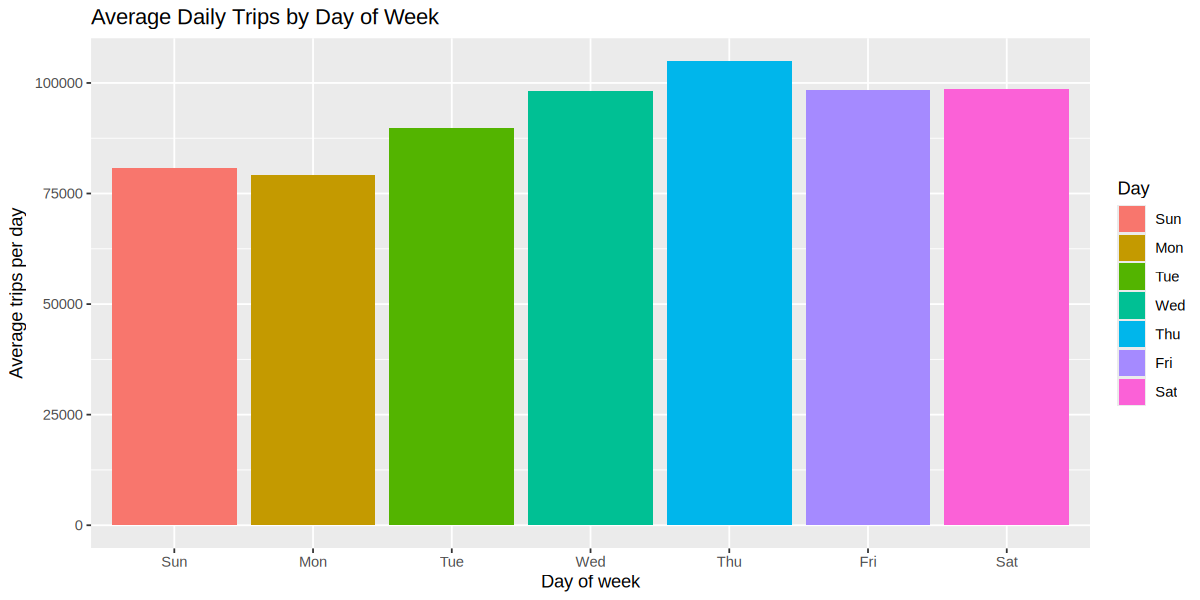

In [28]:
ggplot(by_wday, aes(x = pickup_wday, y = avg_trips_per_day, fill = pickup_wday)) +
  geom_col() +
  labs(title = "Average Daily Trips by Day of Week", x = "Day of week", y = "Average trips per day", fill = "Day")

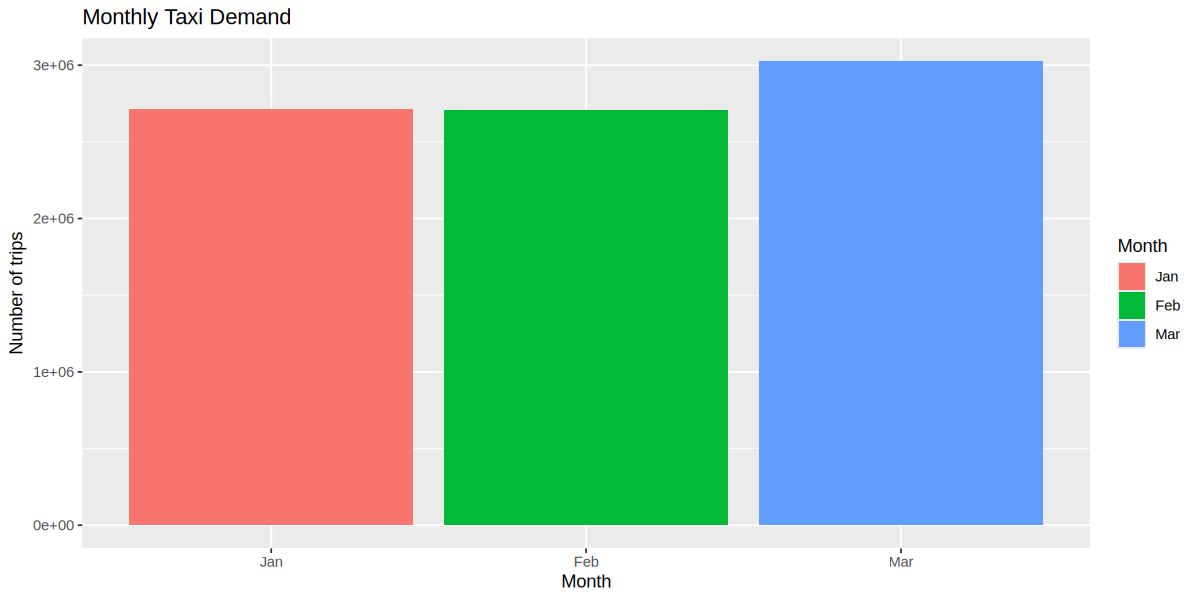

In [29]:
ggplot(by_month, aes(x = pickup_month, y = trips, fill = pickup_month)) +
  geom_col() +
  labs(title = "Monthly Taxi Demand", x = "Month", y = "Number of trips", fill = "Month")

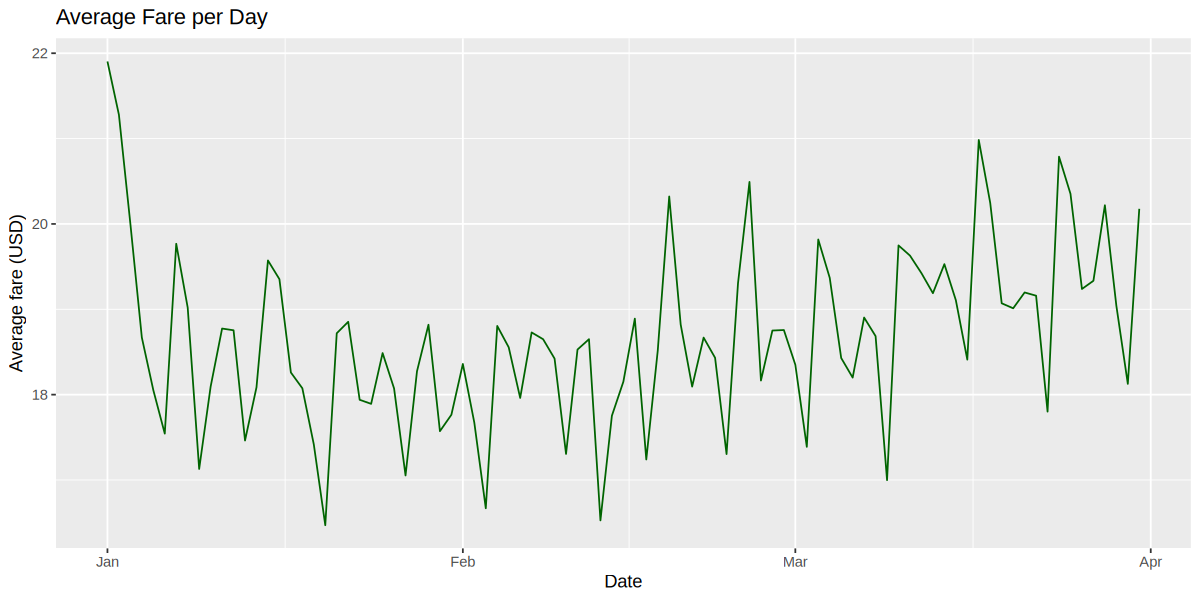

In [30]:
ggplot(daily, aes(x = pickup_date, y = avg_fare)) +
  geom_line(color = "darkgreen") +
  labs(title = "Average Fare per Day", x = "Date", y = "Average fare (USD)")

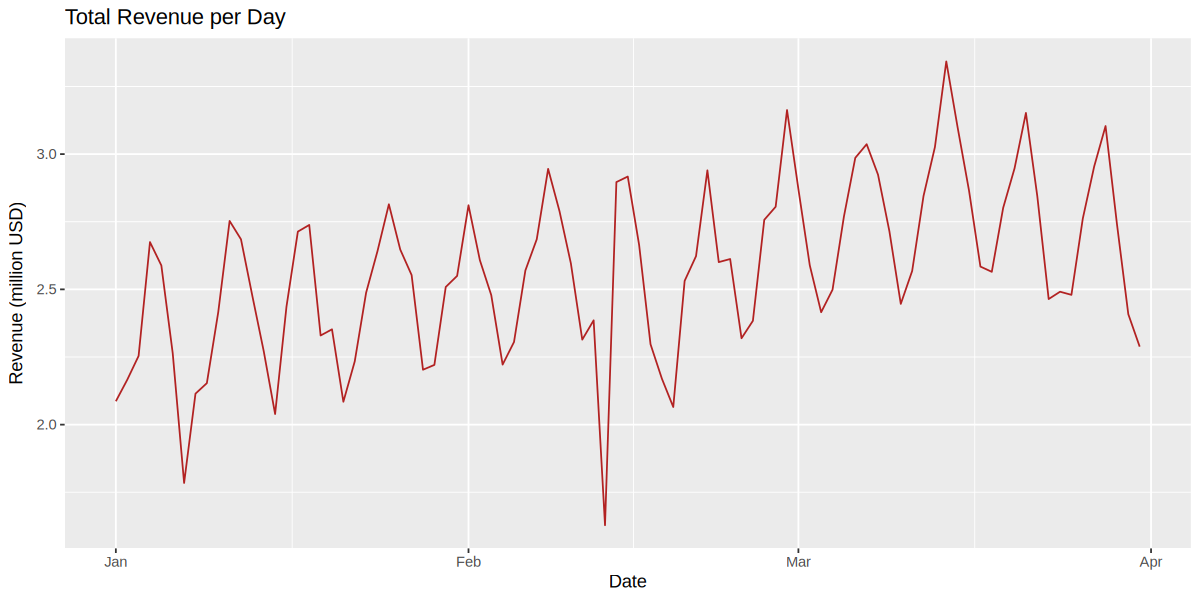

In [31]:
ggplot(daily, aes(x = pickup_date, y = revenue / 1e6)) +
  geom_line(color = "firebrick") +
  labs(title = "Total Revenue per Day", x = "Date", y = "Revenue (million USD)")

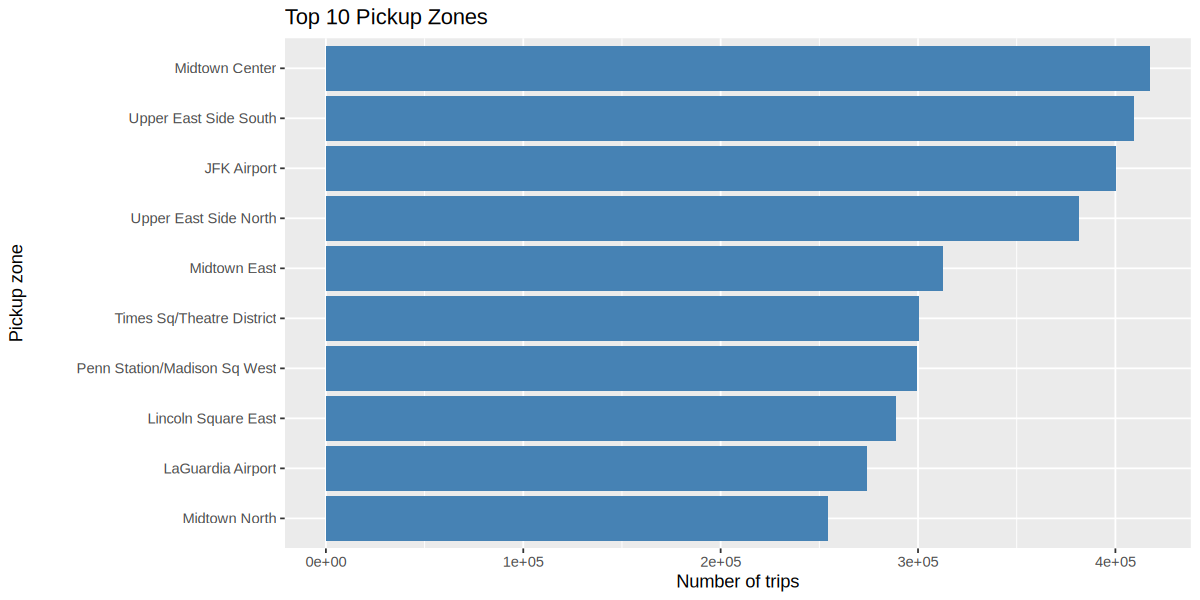

In [32]:
top_pu <- DT[, .(trips = .N), by = PU_Zone][order(-trips)][1:10]

ggplot(top_pu, aes(x = reorder(PU_Zone, trips), y = trips)) +
  geom_col(fill = "steelblue") +
  coord_flip() +
  labs(title = "Top 10 Pickup Zones", x = "Pickup zone", y = "Number of trips")

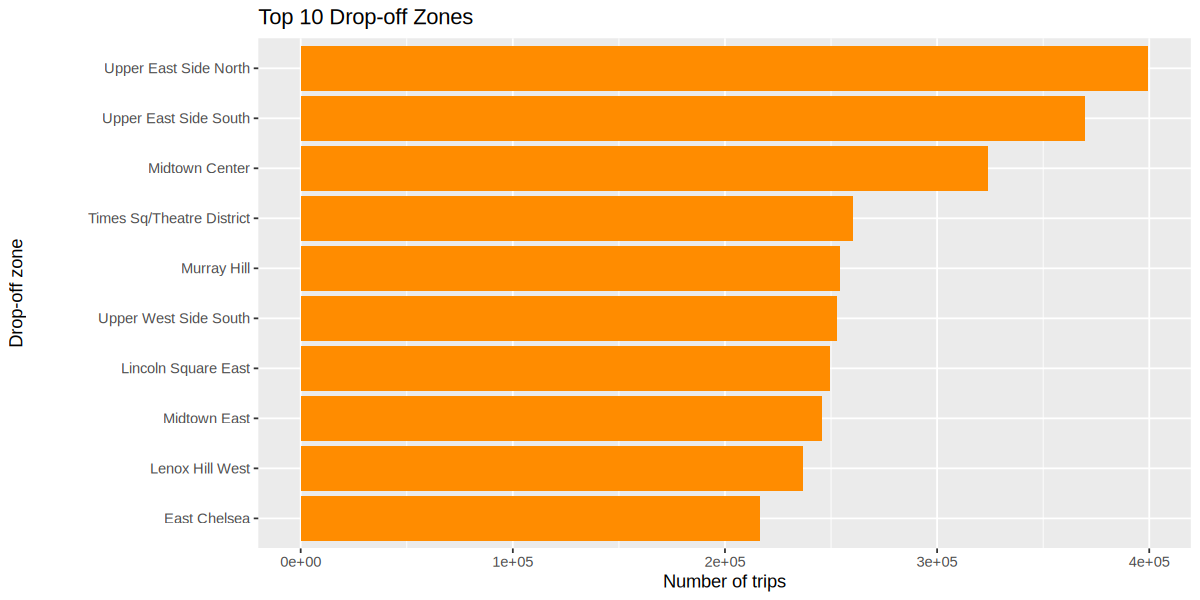

In [33]:
top_do <- DT[, .(trips = .N), by = DO_Zone][order(-trips)][1:10]

ggplot(top_do, aes(x = reorder(DO_Zone, trips), y = trips)) +
  geom_col(fill = "darkorange") +
  coord_flip() +
  labs(title = "Top 10 Drop-off Zones", x = "Drop-off zone", y = "Number of trips")

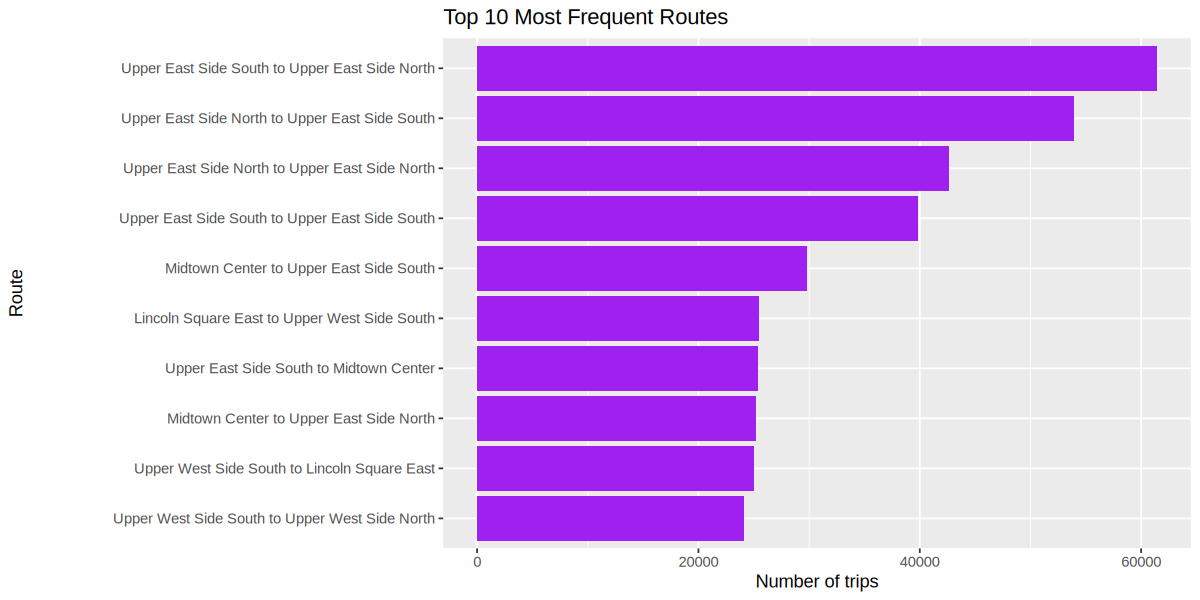

In [34]:
top_routes[, route := paste(PU_Zone, "to", DO_Zone)]

ggplot(top_routes, aes(x = reorder(route, trips), y = trips)) +
  geom_col(fill = "purple") +
  coord_flip() +
  labs(title = "Top 10 Most Frequent Routes", x = "Route", y = "Number of trips")

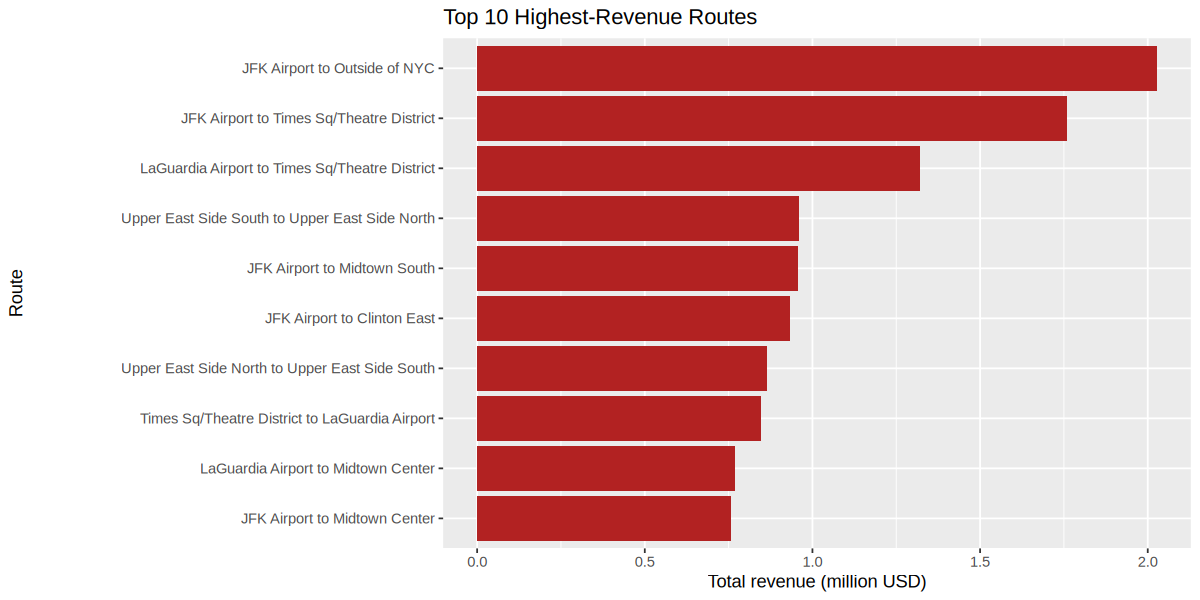

In [35]:
top_revenue[, route := paste(PU_Zone, "to", DO_Zone)]

ggplot(top_revenue, aes(x = reorder(route, revenue), y = revenue / 1e6)) +
  geom_col(fill = "firebrick") +
  coord_flip() +
  labs(title = "Top 10 Highest-Revenue Routes", x = "Route", y = "Total revenue (million USD)")

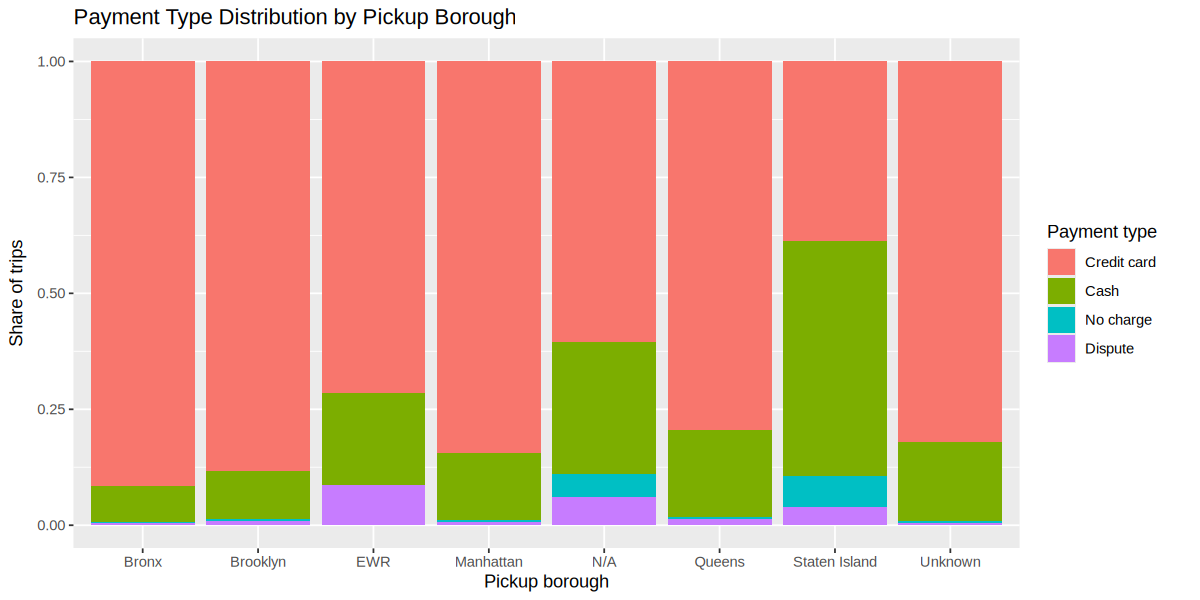

In [36]:
pay <- DT[, .(trips = .N), by = .(PU_Borough, payment)]

ggplot(pay, aes(x = PU_Borough, y = trips, fill = payment)) +
  geom_col(position = "fill") +
  labs(title = "Payment Type Distribution by Pickup Borough", x = "Pickup borough", y = "Share of trips", fill = "Payment type")

`geom_smooth()` using formula = 'y ~ x'


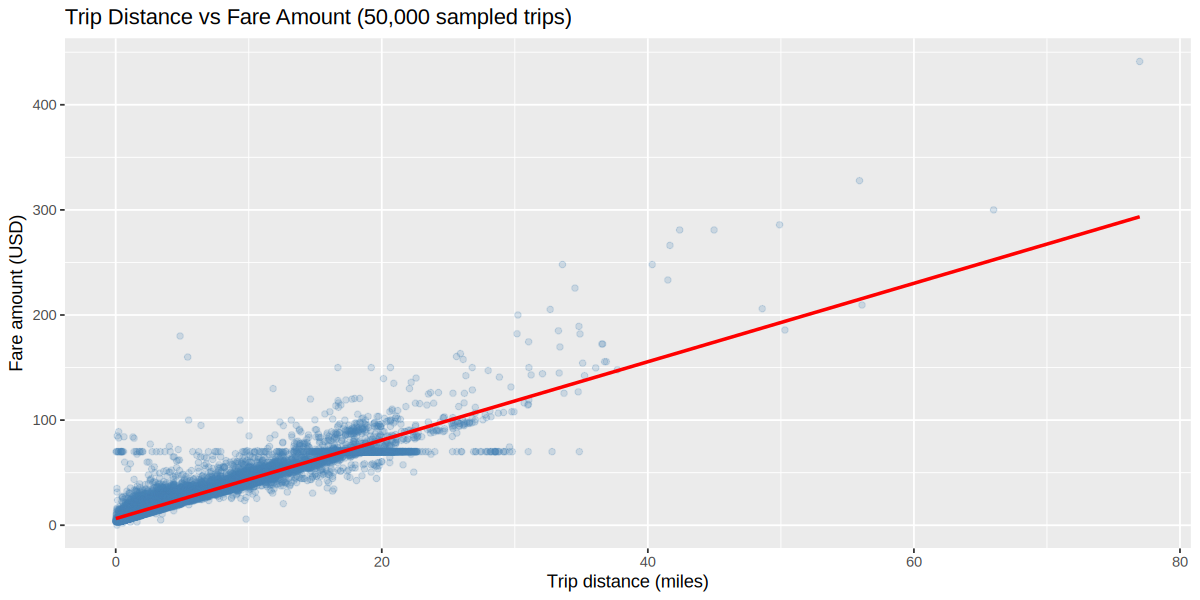

In [37]:
s <- DT[sample(.N, 50000)]

ggplot(s, aes(x = trip_distance, y = fare_amount)) +
  geom_point(alpha = 0.2, color = "steelblue") +
  geom_smooth(method = "lm", color = "red") +
  labs(title = "Trip Distance vs Fare Amount (50,000 sampled trips)", x = "Trip distance (miles)", y = "Fare amount (USD)")

In [38]:
results
cat("\nFastest approach in Task 3:", results[1:6][which.min(Time_sec), Approach], "\n")
cat("Parallel speedup:", round(speedup, 2), "\n")

Approach,Time_sec,Peak_Mem_MB
<chr>,<dbl>,<dbl>
Base R tapply(),0.4739,353.8
apply(),0.8597,1327.9
lapply(),0.8011,1327.9
purrr::map_dbl(),0.8459,1328.2
Vectorized rowsum(),0.3980,289.1
data.table,0.2288,237.5
Sequential (lapply over months),41.6900,NA
"Parallel (foreach, doParallel, 2 cores)",38.3400,NA



Fastest approach in Task 3: data.table 
Parallel speedup: 1.09 


# Theory, Observations and Conclusion

## 1. Problem Statement
Analyse large-scale NYC Yellow Taxi data in R using data.table, compare functional (apply, lapply, purrr::map), vectorized and data.table implementations, compare sequential and parallel (foreach + doParallel) processing, benchmark them, visualize the findings with ggplot2 and critically evaluate the approaches.

## 2. Dataset
NYC TLC Yellow Taxi Trip Records (Jan-Mar 2024, official parquet files, about 9 million trips) and the Taxi Zone Lookup Table, which maps Location IDs to Zone and Borough. Source: https://www.nyc.gov/site/tlc/about/tlc-trip-record-data.page

## 3. Data Preparation
- Only the required columns were imported to save memory.
- Missing values, duplicates and invalid records were removed (zero or negative distance, fare or total, passenger count outside 1-6, trip duration outside 1-180 minutes, unknown payment type, trips outside the selected months).
- Data types were converted, and hour, day, day of week and month were extracted from the pickup time.
- Pickup and drop-off Location IDs were joined with the Zone Lookup Table using data.table.

## 4. Observations (Task 2 and Task 6)
- Trips by hour: lowest around [hour], highest around [hour].
- Day of week: [busiest day] has the most trips per day and [quietest day] the fewest.
- Monthly: [month] has the highest demand.
- Fare and revenue: revenue follows trip volume. Average fare is [higher/lower] at night because of longer trips and airport rides.
- Top zones: Manhattan zones such as [zone] dominate pickups and drop-offs.
- Routes: the most frequent routes are [route], and the highest-revenue routes are [route], often involving airports because of higher fares.
- Distance vs fare: strong positive, almost linear relationship (correlation = [value]).
- Payments: credit card is the most common payment type in every borough, followed by cash.
- Additional pattern: average speed is lowest during [hours] because of traffic congestion.

## 5. Task 3: Functional vs Vectorized vs data.table
- apply, lapply and map_dbl call an R function once per element or group, and here they scan the whole dataset once per hour, so they are slower and create temporary copies.
- Vectorized operations process a whole column in one pass in compiled C code.
- data.table uses optimised, multi-threaded C code for grouping and works by reference without copying data, so it is the fastest and most memory-efficient.
- Readability: data.table and vectorized code are the shortest. Functional code is easy to read and flexible but slower.

## 6. Task 4: Parallel Computing
- Data was partitioned month-wise. The heavy operation was a bootstrap of the mean fare.
- Sequential time = [t_seq] s, parallel time = [t_par] s, so speedup = [t_seq / t_par] with [n] cores.
- The speedup is lower than the number of cores because of worker start-up, copying data to workers and uneven tasks (3 monthly tasks on [n] cores).
- Parallel processing helps only when each task is heavy enough to outweigh this overhead.

## 7. Task 5: Benchmarking Analysis
- Execution time and memory: see the comparison table. The fastest approach was [approach] and the slowest was [approach].
- Scalability: functional approaches repeat work for each group, so their time grows with data size and number of groups. data.table and vectorized code scale much better.
- Complexity and readability: data.table needs one short line, vectorized code needs one extra step, functional code needs an anonymous function.

## 8. Task 7: Critical Analysis
1. Best performance: data.table ([time] s vs [slowest time] s for the slowest approach).
2. data.table is fast because it groups, filters and joins in optimised multi-threaded C code and updates by reference without copying data.
3. Functional programming is preferable when each element or group needs a custom function, for small data, or when readability matters more than speed.
4. Vectorized operations are better for whole-column arithmetic and comparisons, because the loop runs in compiled code instead of calling an R function for every element.
5. Parallel computing gave a speedup of [value].
6. Parallel computing does not always make code faster. The speedup was below the number of cores because of overhead, and for fast operations such as the data.table aggregation, parallel overhead can make it slower than sequential.
7. Trade-offs: data.table is fastest and most memory-efficient but has its own syntax. Base R needs no extra package but is slower. Functional code is flexible but slower and uses more temporary memory. Parallel code is faster for heavy tasks but needs more memory and more code.
8. Recommendation: use data.table for data preparation, joins and aggregation, vectorized operations for column calculations, functional programming only for custom per-group logic, and foreach + doParallel only for heavy, independent tasks.

## 9. Conclusion
On about 9 million real NYC taxi trips, data.table and vectorized code were clearly faster than functional approaches and Base R, and parallel processing gave a speedup of [value] for a computationally heavy task, but not a perfect one. An efficient R workflow should use data.table for data handling, vectorization for calculations, and parallelism only where the computation is heavy enough to justify the overhead.